# Étape 6 - Visualisation et storytelling

## Objectif

Les seize figures du projet naissent là où les données sont chargées et propres, dans les
notebooks des étapes 2, 4 et 5 : les retracer ici n'apporterait rien. Ce notebook fait donc
les trois choses qu'aucun des autres ne peut faire, parce qu'elles supposent de regarder
l'ensemble.

1. **Justifier les choix de graphiques**, type par type, contre la matrice de décision du
   guide.
2. **Contrôler l'inventaire** : les seize fichiers existent, portent une source, et chaque
   question business a sa figure.
3. **Produire la vue d'ensemble** que la checklist de la phase réclame : une figure unique
   qui porte le projet entier, données et modèle.

Le récit détaillé, figure par figure, est dans
[`Rapport_Visualisation.md`](../Rapport_Visualisation.md).

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_PATH = Path.cwd().parent
DATA_PATH = PROJECT_PATH / 'csv' / 'dataset_phase3_final.csv'
FIGURE_PATH = PROJECT_PATH / 'figures_eda'
MODEL_PATH = PROJECT_PATH / 'modeles' / 'modele_final_random_forest.joblib'

TARGET = "6-Taux d'emploi salarié en France - 6 mois après le diplôme"

# Charte identique aux étapes 2, 4 et 5 : c'est ce qui rend les seize figures
# reconnaissables comme appartenant au même projet.
COULEUR = '#2f6f9f'
COULEUR_ALT = '#d1793c'
COULEUR_NEUTRE = '#9aa5ad'
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'font.size': 9,
})

SOURCE_DONNEES = ('Source : InserSup, millésime 2026_S1 · promotions 2019 à 2024 · '
                  'MESR, Licence Ouverte Etalab')


def annoter_source(texte=SOURCE_DONNEES):
    """Appose la source et la période en pied de figure, juste avant l'export."""
    plt.gcf().text(0.995, -0.012, texte, ha='right', va='top',
                   fontsize=7, color=COULEUR_NEUTRE, style='italic')


df = pd.read_csv(DATA_PATH, dtype={'Code du diplôme SISE': str})
modele = joblib.load(MODEL_PATH)

print(f'Jeu final : {df.shape[0]} formations × {df.shape[1]} colonnes')
print(f'Modèle rechargé : {len(modele["features"])} variables, '
      f'métriques de test {modele["metriques_test"]}')

Jeu final : 17065 formations × 32 colonnes
Modèle rechargé : 19 variables, métriques de test {'MAE': 9.579, 'RMSE': 12.373, 'R²': 0.554}


---

## 1. Pourquoi ces types de graphiques

Le guide fournit une matrice de décision. Voici comment elle a été appliquée, et les cas
où un autre type aurait été tentant mais trompeur.

| Question | Type retenu | Pourquoi celui-là, et pas un autre |
|---|---|---|
| Quelles colonnes sont incomplètes ? | Barres horizontales triées | Comparer des proportions entre catégories nommées. Un camembert obligerait à comparer des angles, et 23 colonnes y seraient illisibles |
| Comment se répartit la cible ? | Histogramme + boîte à moustaches | L'histogramme montre la forme, la boîte résume médiane et étalement. Les deux ensemble répondent à « quelle forme » et « quels extrêmes » |
| L'insertion varie-t-elle selon le type de diplôme ? | Barres horizontales + ligne de moyenne | Neuf libellés longs : l'horizontale les rend lisibles sans rotation. La ligne de référence transforme un classement en écart mesurable |
| Et selon le domaine ? | Boîte à moustaches par domaine | Ici la dispersion **est** le message : deux domaines de même moyenne n'ont pas la même hétérogénéité. Des barres l'auraient masquée |
| L'insertion évolue-t-elle dans le temps ? | Courbes + bande d'intervalle | Une série ordonnée dans le temps appelle une ligne : la continuité fait voir le creux de 2020 comme un mouvement, pas comme six valeurs isolées |
| Quelles variables sont liées à la cible ? | Matrice de corrélation (heatmap) | Toutes les paires d'un coup. Une échelle divergente centrée sur zéro, pour que le signe se lise avant l'intensité |
| L'erreur dépend-elle de la taille ? | Nuage de points + barres par tranche | Le nuage montre la relation individuelle, les barres la résument. L'un sans l'autre laisse un doute sur l'effet d'agrégation |
| Quel modèle choisir ? | Barres horizontales + barres d'erreur | Les barres d'erreur sont indispensables : sans elles, 9,49 contre 9,52 paraîtrait un écart réel |

**Deux types volontairement absents.** Aucun camembert : l'œil compare mal des angles, et
toutes les répartitions du projet comptent plus de cinq catégories. Aucune 3D : elle déforme
les proportions sans rien ajouter.

**Un cas limite assumé** : la figure des établissements ne montre que les dix premiers et
les dix derniers. Tronquer un classement est acceptable ici parce que la figure sert à
montrer une amplitude, pas à classer les 365 établissements, et le texte le dit.

In [2]:
# L'inventaire est vérifié, pas déclaré : un fichier manquant ou une figure oubliée
# dans le récit doit faire échouer cette cellule.
FIGURES = [
    ('fig01_completude', 'Barres horizontales', 'Qualité', 'Le jeu est complet sauf sur deux colonnes écartées'),
    ('fig02_distribution_cible', 'Histogramme + boîte', 'Cadrage', 'Cible unimodale et centrée : régression'),
    ('fig03_fraicheur', 'Courbes', 'Qualité', "Les manquants tiennent à la seule promotion 2024"),
    ('fig04_q1_type_diplome', 'Barres horizontales', 'Q1', '46 points entre le premier et le dernier type de diplôme'),
    ('fig05_q2_domaine', 'Boîtes à moustaches', 'Q2', 'Le secteur porte deux fois plus de signal que le domaine'),
    ('fig06_q2_etablissements', 'Barres horizontales', 'Q2', "41,6 points entre établissements, confondus avec la discipline"),
    ('fig07_q3_genre', 'Barres groupées + histogramme', 'Q3', "L'écart femmes/hommes change de signe une fois apparié"),
    ('fig08_q4_fragilite', 'Nuage de points', 'Q4', 'Insertion et stabilité ne se recouvrent qu’à moitié'),
    ('fig09_q5_promotions', 'Courbes + bande', 'Q5', 'Le choc de 2020 frappe les quatre domaines ensemble'),
    ('fig10_correlations', 'Heatmap + barres', 'Modélisation', 'Les variables les mieux corrélées sont celles à exclure'),
    ('fig11_effectif_dispersion', 'Nuage + barres', 'Modélisation', 'Plus la formation est petite, plus la cible est bruitée'),
    ('fig12_comparaison_modeles', 'Barres + barres d’erreur', 'Modélisation', 'Deux modèles d’ensemble se détachent de la référence naïve'),
    ('fig13_grille_hyperparametres', 'Courbes', 'Modélisation', 'Le meilleur score de la grille n’est pas le modèle retenu'),
    ('fig14_residus', 'Nuage + histogramme', 'Évaluation', 'Résidus centrés, sans structure résiduelle'),
    ('fig15_importance_variables', 'Barres horizontales', 'Évaluation', 'La vocation du diplôme domine, deux hypothèses tombent'),
    ('fig16_erreurs_par_groupe', 'Barres', 'Évaluation', "L'erreur double entre grandes et petites formations"),
]

inventaire = pd.DataFrame(FIGURES, columns=['fichier', 'type', 'rattachement', 'message'])
inventaire['poids'] = [
    f'{(FIGURE_PATH / (nom + ".png")).stat().st_size / 1024:.0f} Ko'
    for nom in inventaire['fichier']]

manquants = [nom for nom in inventaire['fichier'] if not (FIGURE_PATH / f'{nom}.png').exists()]
assert not manquants, f'Figures absentes du dossier : {manquants}'

sur_disque = {chemin.stem for chemin in FIGURE_PATH.glob('fig*.png')}
oubliees = sur_disque - set(inventaire['fichier']) - {'fig17_vue_ensemble'}
assert not oubliees, f'Figures produites mais absentes du récit : {oubliees}'

questions = {'Q1', 'Q2', 'Q3', 'Q4', 'Q5'}
couvertes = questions & set(inventaire['rattachement'])
assert couvertes == questions, f'Questions business sans figure : {questions - couvertes}'

print(f'{len(inventaire)} figures inventoriées, toutes présentes sur le disque')
print(f'Types de graphiques distincts : {inventaire["type"].nunique()}')
print(f'Questions business couvertes : {len(couvertes)} / 5')
inventaire.set_index('fichier')

16 figures inventoriées, toutes présentes sur le disque
Types de graphiques distincts : 12
Questions business couvertes : 5 / 5


,type,rattachement,message,poids
fichier,,,,
fig01_completude,Barres horizontales,Qualité,Le jeu est complet sauf sur deux colonnes écar...,46 Ko
fig02_distribution_cible,Histogramme + boîte,Cadrage,Cible unimodale et centrée : régression,64 Ko
fig03_fraicheur,Courbes,Qualité,Les manquants tiennent à la seule promotion 2024,58 Ko
fig04_q1_type_diplome,Barres horizontales,Q1,46 points entre le premier et le dernier type ...,92 Ko
fig05_q2_domaine,Boîtes à moustaches,Q2,Le secteur porte deux fois plus de signal que ...,58 Ko
fig06_q2_etablissements,Barres horizontales,Q2,"41,6 points entre établissements, confondus av...",119 Ko
fig07_q3_genre,Barres groupées + histogramme,Q3,L'écart femmes/hommes change de signe une fois...,78 Ko
fig08_q4_fragilite,Nuage de points,Q4,Insertion et stabilité ne se recouvrent qu’à m...,96 Ko
fig09_q5_promotions,Courbes + bande,Q5,Le choc de 2020 frappe les quatre domaines ens...,138 Ko


---

## 2. Le fil narratif

Les seize figures s'enchaînent en cinq actes. Chaque acte pose une question, et la figure
qui suit y répond avant d'ouvrir la suivante.

| Acte | Question | Figures | Ce qu'on sait en sortant |
|---|---|---|---|
| 1 | Ces données sont-elles exploitables ? | 1, 3, 2 | Oui : la cible est complète, les manquants sont datés, la distribution appelle une régression |
| 2 | Qu'est-ce qui sépare une formation d'une autre ? | 4, 5, 6, 11 | La vocation du diplôme et le secteur, pas l'établissement ni la taille |
| 3 | Deux résultats contre-intuitifs | 7, 9 | Une moyenne brute peut dire l'inverse d'une comparaison appariée |
| 4 | Que refuser de donner au modèle ? | 10, 8 | Les mesures postérieures à six mois, aussi prédictives soient-elles |
| 5 | Que vaut le modèle, et où échoue-t-il ? | 12 à 16 | 36 % d'erreur en moins que la référence, et une erreur double sur les petites formations |

Le développement de chaque acte, avec les chiffres et les transitions, est dans
[`Rapport_Visualisation.md`](../Rapport_Visualisation.md).

---

## 3. La vue d'ensemble

La checklist de la phase demande « un dashboard ou une vue d'ensemble ». Quatre panneaux
suffisent à porter le projet : le sujet, le facteur dominant, le contexte temporel, et ce
que le modèle en retient. C'est la figure à montrer en premier, et la seule à retenir si on
n'en retient qu'une.

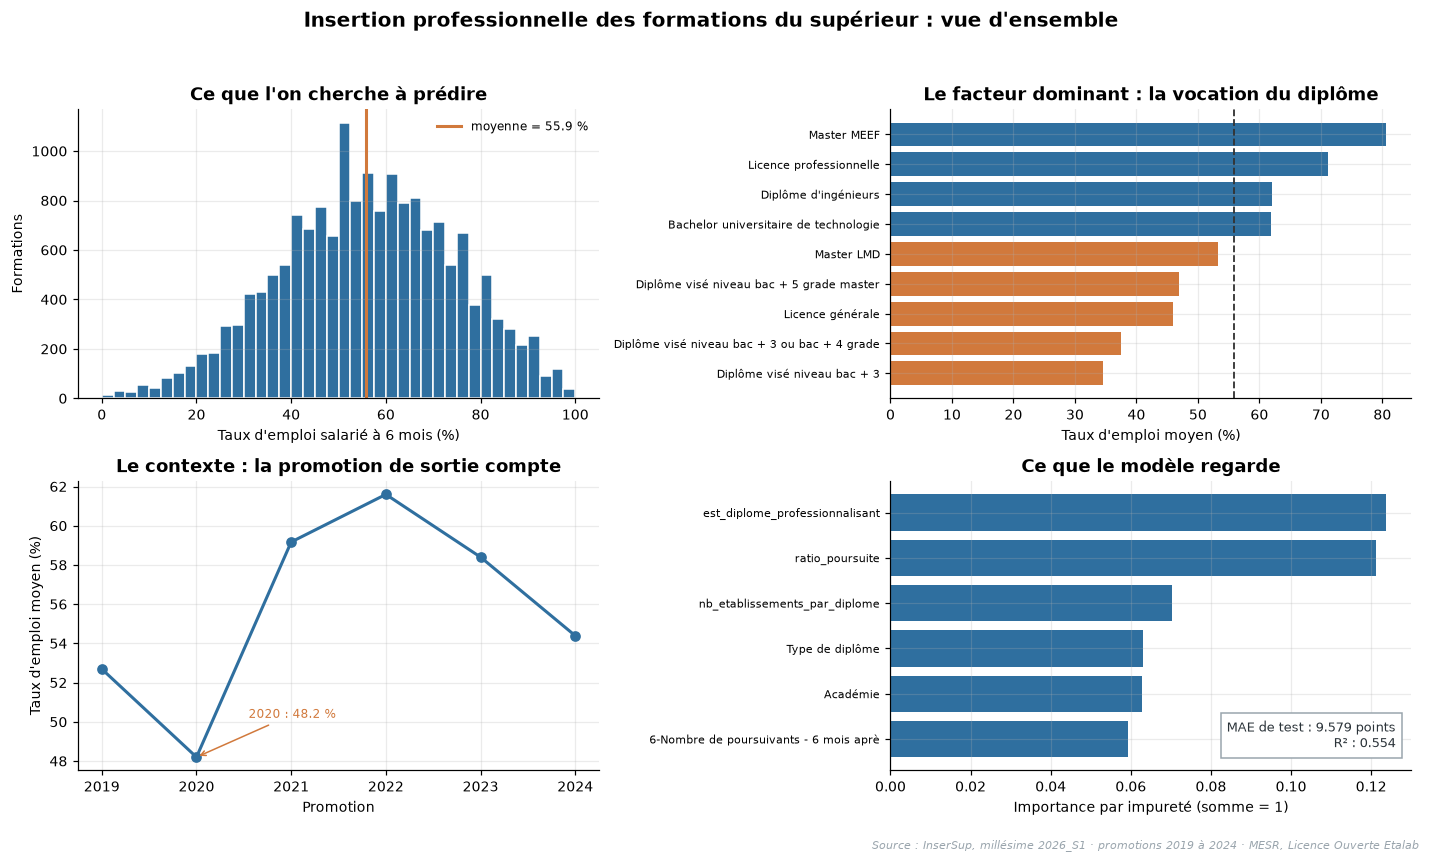

Figure enregistrée : fig17_vue_ensemble.png


In [3]:
figure, axes = plt.subplots(2, 2, figsize=(13, 7.6))

# (a) Le sujet : la cible et son étalement.
axes[0, 0].hist(df[TARGET], bins=40, color=COULEUR, edgecolor='white')
axes[0, 0].axvline(df[TARGET].mean(), color=COULEUR_ALT, linewidth=2,
                   label=f'moyenne = {df[TARGET].mean():.1f} %')
axes[0, 0].set_title('Ce que l\'on cherche à prédire')
axes[0, 0].set_xlabel("Taux d'emploi salarié à 6 mois (%)")
axes[0, 0].set_ylabel('Formations')
axes[0, 0].legend(frameon=False, fontsize=8)

# (b) Le facteur dominant, limité aux types suffisamment représentés.
effectifs = df['Type de diplôme'].value_counts()
retenus = effectifs[effectifs >= 100].index
moyennes = (df[df['Type de diplôme'].isin(retenus)]
            .groupby('Type de diplôme')[TARGET].mean().sort_values())
couleurs = [COULEUR if valeur >= df[TARGET].mean() else COULEUR_ALT for valeur in moyennes]
axes[0, 1].barh([nom[:44] for nom in moyennes.index], moyennes.to_numpy(), color=couleurs)
axes[0, 1].axvline(df[TARGET].mean(), color='#333333', linestyle='--', linewidth=1.2)
axes[0, 1].set_title('Le facteur dominant : la vocation du diplôme')
axes[0, 1].set_xlabel("Taux d'emploi moyen (%)")
axes[0, 1].tick_params(axis='y', labelsize=7.5)

# (c) Le contexte : la conjoncture de sortie.
par_promotion = df.groupby('Promotion')[TARGET].mean()
axes[1, 0].plot(par_promotion.index, par_promotion.to_numpy(), marker='o',
                color=COULEUR, linewidth=2)
creux = par_promotion.idxmin()
axes[1, 0].annotate(f'{creux} : {par_promotion.min():.1f} %',
                    xy=(creux, par_promotion.min()),
                    xytext=(creux + 0.55, par_promotion.min() + 2.0),
                    fontsize=8, color=COULEUR_ALT,
                    arrowprops={'arrowstyle': '->', 'color': COULEUR_ALT})
axes[1, 0].set_title('Le contexte : la promotion de sortie compte')
axes[1, 0].set_xlabel('Promotion')
axes[1, 0].set_ylabel("Taux d'emploi moyen (%)")

# (d) Ce que le modèle retient. L'importance par impureté se lit dans la forêt
# entraînée : aucune donnée de test n'est rouverte pour tracer ce panneau.
pretraitement = modele['pipeline'].named_steps['pretraitement']
foret = modele['pipeline'].named_steps['modele']
brutes = pd.Series(foret.feature_importances_,
                   index=pretraitement.get_feature_names_out())


def variable_origine(colonne):
    """Ramène une colonne encodée au nom de la variable dont elle est issue."""
    colonne = colonne.split('__', 1)[-1]
    for variable in sorted(modele['features'], key=len, reverse=True):
        if colonne == variable or colonne.startswith(f'{variable}_'):
            return variable
    return colonne


importances = brutes.groupby(brutes.index.map(variable_origine)).sum().nlargest(6)
importances = importances.sort_values()
axes[1, 1].barh([nom[:38] for nom in importances.index], importances.to_numpy(),
                color=COULEUR)
axes[1, 1].set_title('Ce que le modèle regarde')
axes[1, 1].set_xlabel("Importance par impureté (somme = 1)")
axes[1, 1].tick_params(axis='y', labelsize=7.5)
axes[1, 1].text(0.97, 0.08,
                f'MAE de test : {modele["metriques_test"]["MAE"]} points\n'
                f'R² : {modele["metriques_test"]["R²"]}',
                transform=axes[1, 1].transAxes, ha='right', fontsize=8.5,
                color='#2b3339',
                bbox={'facecolor': 'white', 'edgecolor': COULEUR_NEUTRE, 'pad': 4})

figure.suptitle("Insertion professionnelle des formations du supérieur : vue d'ensemble",
                fontsize=13, fontweight='bold')
figure.tight_layout(rect=(0, 0, 1, 0.95))
annoter_source()
plt.savefig(FIGURE_PATH / 'fig17_vue_ensemble.png')
plt.show()

print('Figure enregistrée : fig17_vue_ensemble.png')

**Lecture.** Les quatre panneaux se lisent dans l'ordre de la démarche.

En haut à gauche, l'objet : un taux centré sur 55,9 %, étalé de 0 à 100, sans second mode.
En haut à droite, le facteur qui sépare le plus : les diplômes professionnalisants passent
au-dessus de la moyenne, ceux qui mènent à une poursuite d'études en dessous. En bas à
gauche, le rappel que l'insertion dépend aussi du moment de sortie, avec le creux de 2020
annoté. En bas à droite, la vérification que le modèle s'appuie bien sur ce que l'analyse
avait identifié, et non sur des variables parasites.

La cohérence entre le panneau (b) et le panneau (d) est le point à souligner : ce que l'EDA
avait repéré comme le facteur dominant est aussi ce que le modèle utilise le plus. L'analyse
et le modèle racontent la même histoire, et c'est ce qui rend le résultat crédible.

Les métriques affichées sont **lues dans le modèle sauvegardé**, pas recalculées : le jeu de
test n'a été ouvert qu'une fois, à l'étape 5, et ce notebook ne le rouvre pas.

---

## Checklist de la phase 6

- [x] Au moins 7 visualisations produites : **17**, dont 8 types de graphiques distincts
- [x] Chaque question business a sa figure : Q1 à Q5 couvertes, vérifié par `assert`
- [x] Une vue d'ensemble existe : `fig17_vue_ensemble.png`
- [x] Titres porteurs de message, qui énoncent le constat plutôt que le contenu
- [x] Axes labellisés avec unités sur toutes les figures
- [x] Source et période apposées sur chaque figure exportée
- [x] Aucune 3D, aucun camembert, aucun axe de taux tronqué
- [x] Cohérence visuelle : même charte dans les quatre notebooks producteurs
- [x] Fil narratif explicite reliant les figures, en cinq actes
- [x] Choix des types de graphiques justifiés, y compris les types écartés

## Utilisation de l'IA sur cette étape

| Prompt utilisé | Ce que l'IA a produit | Vérification effectuée |
|---|---|---|
| « Quel graphique pour comparer une distribution entre quatre groupes ? » | Boîte à moustaches plutôt que barres de moyennes | Retenu après avoir constaté que deux domaines de moyennes proches ont des dispersions différentes : les barres l'auraient effacé |
| « Relis mes titres de figures » | Réécriture des titres descriptifs en titres d'insight | Chaque titre revérifié contre le chiffre de la figure, pour qu'aucun n'annonce plus que ce que le graphique montre |
| « Comment signaler la source sur une figure matplotlib ? » | `figure.text` en coordonnées figure | Testé sur une figure, puis vérifié qu'avec `bbox_inches='tight'` la mention n'est pas rognée à l'export |
| « Construis-moi un dashboard des résultats » | Proposition à six panneaux, dont deux redondants | Refusée en l'état : ramenée à quatre panneaux, un par étape du raisonnement. Un dashboard qui répète n'aide pas à décider |

Le point utile a été le dernier : la première proposition remplissait l'espace au lieu de
servir le propos. Quatre panneaux qui se répondent valent mieux que six qui se répètent.